# 03 — Country mask

Rasterises Natural Earth 1:50m `admin_0` country polygons onto the shared 0.5° grid via `dominant_region_mask` and caches the result to `country_mask.nc`. Every variable notebook that scores by country (`19_climate_vulnerability`, `31_income`, `32_cost_of_living`, `33_crime_rate`, `34_human_freedom`, `35_corruption`) loads that cache instead of downloading Natural Earth and re-running the ~250-region fractional-coverage mask itself.

The cache stores ISO3 codes per cell rather than opaque polygon indices, so downstream notebooks can join score tables on ISO3 directly without knowing anything about the polygon layer that produced the mask.

In [1]:
import geopandas as gpd
import httpx
import numpy as np
import regionmask
import xarray as xr

from common import PROCESSED_DIR, RAW_DIR, dominant_region_mask, load_grid

variable_raw = RAW_DIR / 'region_mask'
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch admin_0 countries

Natural Earth 1:50m admin_0 boundaries (~4 MB). 50m is the same resolution the country-scored notebooks were using before this cache existed — high enough to place small island states correctly on a 0.5° grid without the download cost of 1:10m.

In [2]:
NE_URL = 'https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip'
ne_zip = variable_raw / 'ne_50m_admin_0_countries.zip'

if not ne_zip.exists():
    print(f'downloading {NE_URL}')
    r = httpx.get(NE_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ne_zip.write_bytes(r.content)

print(f'{ne_zip.name}: {ne_zip.stat().st_size / 1024:.0f} KB')

ne_50m_admin_0_countries.zip: 781 KB


## 2. Load country polygons

Keep only `ISO_A3_EH` (which fills in ISO3 codes for disputed / de-facto states that lack an official `ISO_A3`) and geometry. Countries with `-99` for `ISO_A3_EH` (a handful of unrecognised territories) are dropped so every cached cell maps back to a real ISO3 that score tables can join on.

In [3]:
countries = (
    gpd.read_file(f'zip://{ne_zip}')
    .to_crs('EPSG:4326')
    [['ISO_A3_EH', 'NAME', 'CONTINENT', 'geometry']]
    .rename(columns={'ISO_A3_EH': 'ISO3'})
)
countries = countries[countries['ISO3'] != '-99'].reset_index(drop=True)
print(f'{len(countries)} countries with a real ISO3 code')
countries.head()

238 countries with a real ISO3 code


,ISO3,NAME,CONTINENT,geometry
0,ZWE,Zimbabwe,Africa,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,ZMB,Zambia,Africa,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,YEM,Yemen,Asia,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,VNM,Vietnam,Asia,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,VEN,Venezuela,South America,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


## 3. Rasterise onto the atlas grid

`dominant_region_mask` picks the country with the largest fractional coverage per cell, so island cells and coastal cells whose centre sits in the ocean still get an assignment. `overlap=False` skips regionmask's overlap check — adjacent-country borders can produce tiny slivers of overlap that are noise at 0.5°.

In [ ]:
grid = load_grid()

regions = regionmask.from_geopandas(countries, overlap=False)
raw_region_idx = dominant_region_mask(regions, grid.lon, grid.lat)

covered = int(raw_region_idx.notnull().sum())
land = int((grid.is_land == 1).sum())
print(f'{covered:,} cells assigned a country ({100 * covered / land:.1f}% of land cells)')

## 4. Nearest-polygon fallback for coastal / island cells

`02_grid` builds its land mask from Natural Earth **1:10m** land polygons, but this notebook rasterises **1:50m** admin_0 polygons — so a handful of coastal cells and small islands come out as `is_land=1` but have no country assignment (e.g. the 0.5° cell centred on `-23.75°, -70.75°` sits just off the 1:50m Chile coastline near Antofagasta and misses every polygon at 10× oversampling). Left unfixed, every country-level layer (education, happiness, crime, corruption, human freedom, income, vulnerability) is NaN at those cells.

For each unmapped land cell assign the geometrically nearest country polygon via `geopandas.sjoin_nearest`, so the ISO3 lookup resolves for every land cell downstream.

In [ ]:
import warnings
from shapely.geometry import Point

region_idx = raw_region_idx.copy()
gap_mask = raw_region_idx.isnull() & (grid.is_land == 1)
gap_rows, gap_cols = np.where(gap_mask.values)

if gap_rows.size:
    gap_lats = grid.lat.values[gap_rows]
    gap_lons = grid.lon.values[gap_cols]
    points = gpd.GeoDataFrame(
        {'_gap_idx': np.arange(gap_rows.size)},
        geometry=[Point(x, y) for x, y in zip(gap_lons, gap_lats)],
        crs='EPSG:4326',
    )
    # sjoin_nearest on a geographic CRS emits a distance-in-degrees warning;
    # that's fine here — we only need nearest-polygon ordering, not real distance.
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')
        nearest = gpd.sjoin_nearest(points, countries[['geometry']], how='left')
    # Ties (a point equidistant from two borders) return one row per tie — keep the first.
    nearest = nearest.drop_duplicates(subset='_gap_idx', keep='first').sort_values('_gap_idx')
    region_idx.values[gap_rows, gap_cols] = nearest['index_right'].to_numpy(dtype=float)

filled = int((raw_region_idx.isnull() & region_idx.notnull()).sum())
still_missing = int((region_idx.isnull() & (grid.is_land == 1)).sum())
print(f'filled {filled:,} previously-unmapped land cells via nearest polygon')
print(f'remaining land cells with no country: {still_missing}')

## 5. QA: which land cells did the 1:50m polygons miss?

Highlight the cells that were rescued by the nearest-polygon fallback — expect thin coastal fringes (Chilean/Peruvian coast, Norwegian fjords, Alaskan panhandle) and small islands the 1:50m dataset lacks polygon detail for. A useful sanity check if either dependency (the 1:10m land mask in `02_grid` or the 1:50m country polygons here) changes.

In [ ]:
from common import plot_map

unmapped_before = raw_region_idx.isnull() & (grid.is_land == 1)
plot_map(
    unmapped_before.astype(float).where(unmapped_before),
    title='Land cells missed by 1:50m country polygons (filled via nearest polygon)',
    cmap='Reds',
    vmin=0,
    vmax=1,
    add_colorbar=False,
)

## 6. Save

Stored as an int16 `country_idx` grid (-1 sentinel for cells with no country) plus a 1D `iso3` lookup indexed by that value. Cheaper on disk than a 2D string array and portable across any netCDF reader. `common.load_country_mask()` recombines the two into a 2D ISO3-string DataArray for consumers.

In [5]:
from pathlib import Path

idx_arr = region_idx.values
valid = ~np.isnan(idx_arr)
country_idx = np.where(valid, idx_arr, -1).astype('int16')

mask_ds = xr.Dataset(
    {
        'country_idx': (('lat', 'lon'), country_idx),
        'iso3': (('country_num',), countries['ISO3'].to_numpy()),
        'name': (('country_num',), countries['NAME'].to_numpy()),
        'continent': (('country_num',), countries['CONTINENT'].to_numpy()),
    },
    coords={'lat': grid.lat, 'lon': grid.lon},
    attrs={
        'source': 'Natural Earth 1:50m admin_0 countries via dominant_region_mask',
        'sentinel': '-1 in country_idx = no country (ocean / Antarctica / unlisted)',
    },
)

out = PROCESSED_DIR / 'country_mask.nc'
if Path(out).exists():
    Path(out).unlink()
mask_ds.to_netcdf(out)
print(f'wrote {out} ({out.stat().st_size / 1024:.0f} KB)')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/country_mask.nc (566 KB)


## 7. Sanity check

Reload via the shared helper and plot the country index. The pattern should look like a familiar political map with sharp country boundaries — no continent-sized voids where islands were dropped.

unique countries in cache: 226


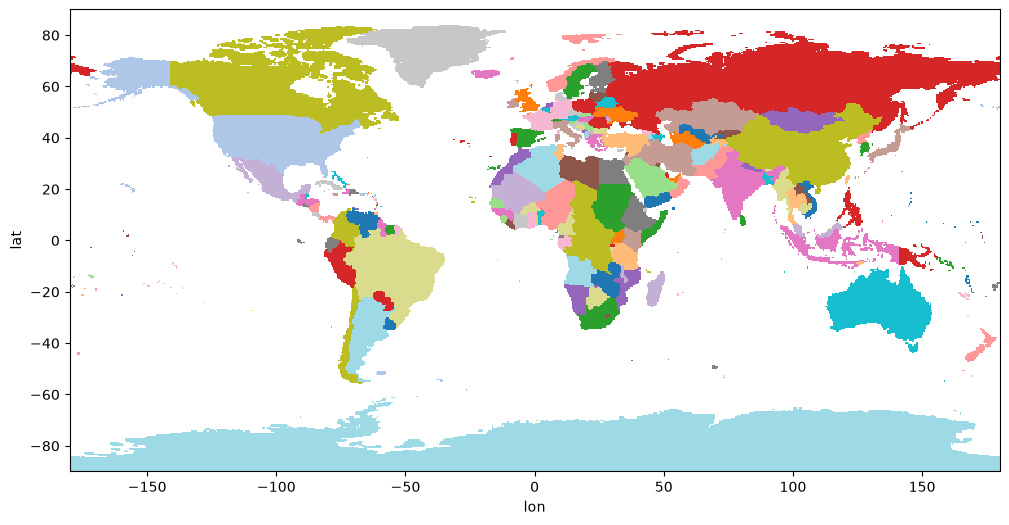

In [6]:
from common import load_country_mask

iso_per_cell = load_country_mask()
print(f'unique countries in cache: {len(set(iso_per_cell.values.ravel())) - 1}')  # minus the empty-string sentinel

# Plot the raw int index — no cmap tweaks needed, we just want to see the country boundaries.
mask_ds['country_idx'].where(mask_ds['country_idx'] >= 0).plot(figsize=(12, 6), cmap='tab20', add_colorbar=False)